# Начальная функция масс «на пальцах»: почему её называют «топ-хэви»

Этот ноутбук — объяснение для нового читателя, шаг за шагом, без предварительных знаний. Разбираем главную идею статьи
Durrant et al. 2026, *"Cosmological simulations of the high-redshift galaxy population adopting a variable stellar initial mass function"*,
arXiv:2607.16404 (§2.2 «Variable IMF implementation»).

## Шаг 1. Что такое начальная функция масс (IMF)

Когда из облака межзвёздного газа рождается новое поколение звёзд, получаются не одинаковые светила, а целый спектр масс —
от тусклых красных карликов в десятые доли массы Солнца до редких голубых гигантов в десятки солнечных масс.

**Начальная функция масс (initial mass function, IMF)** — это и есть рецепт, по которому распределяется эта смесь: сколько
звёзд каждой массы рождается на каждую единицу массы газа, ушедшего в звёзды. Авторы статьи используют ломаный степенной закон:

$$
\frac{dn}{dM} \propto
\begin{cases}
M^{-1.3}, & 0.1 \le M/M_\odot < 0.5 \\
M^{\alpha}, & 0.5 \le M/M_\odot < 100
\end{cases}
$$

Ниже строим и смотрим на эту функцию для «обычного», хорошо изученного случая — с показателем степени $\alpha=-2.3$ на
высокомассовом конце (это стандартная, «канонический» IMF, эквивалентная широко используемой IMF Крупы 2001 года).

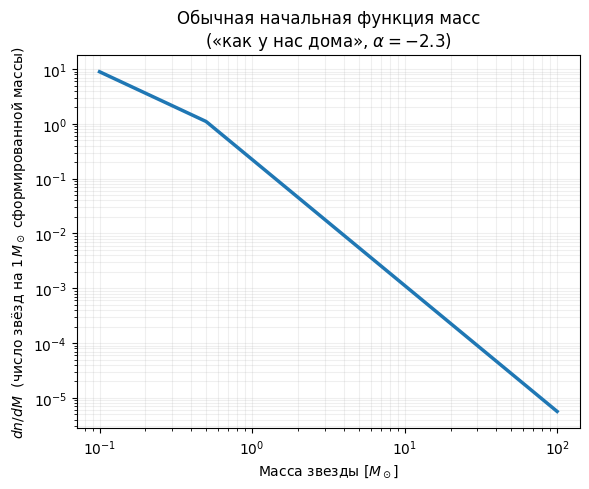

Синтетическая популяция из 1,000,000 звёзд, обычная IMF:
  доля тусклых карликов (< 0.5 Msun): 73%
  доля массивных звёзд (>= 8 Msun):   0.71%  (то есть примерно 1 массивная звезда на каждые 141 новорождённых)


In [1]:
from pathlib import Path

import numpy as np
from scipy import integrate, interpolate
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
OUT_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)

# --- IMF functional form (paper's Eq. 1); parameters from Section 2.2 ---
M_LO, M_BREAK, M_HI = 0.1, 0.5, 100.0   # Msun
X_LOW_MASS = -1.3                        # fixed low-mass slope
ALPHA_KROUPA = -2.3                      # "usual" / canonical high-mass slope
ALPHA_TOPHEAVY = -1.6                    # most top-heavy limit used in the paper


def imf_shape(M, alpha):
    M = np.asarray(M, dtype=float)
    B_over_A = M_BREAK ** (X_LOW_MASS - alpha)
    low = M ** X_LOW_MASS
    high = B_over_A * M ** alpha
    return np.where(M < M_BREAK, low, high)


def normalisation_constant(alpha, n_points=20000):
    M_grid = np.logspace(np.log10(M_LO), np.log10(M_HI), n_points)
    shape = imf_shape(M_grid, alpha)
    mass_integral = integrate.trapezoid(M_grid * shape, M_grid)
    return 1.0 / mass_integral


def imf_dndM(M, alpha):
    return normalisation_constant(alpha) * imf_shape(M, alpha)


def build_sampler(alpha, n_points=20000):
    M_grid = np.logspace(np.log10(M_LO), np.log10(M_HI), n_points)
    dndM = imf_shape(M_grid, alpha)
    cdf = integrate.cumulative_trapezoid(dndM, M_grid, initial=0.0)
    cdf /= cdf[-1]
    return interpolate.interp1d(cdf, M_grid, bounds_error=False, fill_value=(M_LO, M_HI))


def sample_masses(alpha, n_stars, rng):
    inv_cdf = build_sampler(alpha)
    u = rng.uniform(0.0, 1.0, size=n_stars)
    return inv_cdf(u)


# --- Plot: the "usual" IMF alone ---
M_grid = np.logspace(np.log10(M_LO), np.log10(M_HI), 500)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(M_grid, imf_dndM(M_grid, ALPHA_KROUPA), color="#1f77b4", lw=2.5)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Масса звезды [$M_\odot$]")
ax.set_ylabel(r"$dn/dM$  (число звёзд на $1\,M_\odot$ сформированной массы)")
ax.set_title("Обычная начальная функция масс\n(«как у нас дома», $\\alpha=-2.3$)")
ax.grid(alpha=0.2, which="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "imf_explainer_usual.png", dpi=140)
plt.show()

# --- Synthetic population: draw stars and count how many are massive ---
N_STARS = 1_000_000
masses_usual = sample_masses(ALPHA_KROUPA, N_STARS, rng)

frac_dwarfs = np.mean(masses_usual < 0.5)
frac_massive = np.mean(masses_usual >= 8)
one_in_n = 1.0 / frac_massive

print(f"Синтетическая популяция из {N_STARS:,} звёзд, обычная IMF:")
print(f"  доля тусклых карликов (< 0.5 Msun): {frac_dwarfs:.0%}")
print(f"  доля массивных звёзд (>= 8 Msun):   {frac_massive:.2%}  "
      f"(то есть примерно 1 массивная звезда на каждые {one_in_n:.0f} новорождённых)")


## Шаг 2. Что на самом деле видно на этом графике

Это и есть картина звёздообразования «у нас дома» — в окрестностях Солнца, где IMF изучена лучше всего. Обратите внимание,
насколько круто падает кривая слева направо (это логарифмическая шкала по обеим осям, так что падение ещё круче, чем кажется
на глаз): маленьких, тусклых звёзд рождается на порядки больше, чем крупных.

Расчёт выше делает это ощутимым в цифрах: если случайно «родить» миллион звёзд по этому рецепту, около трёх четвертей
окажутся тусклыми карликами легче половины массы Солнца — а по-настоящему массивная звезда (от 8 масс Солнца и выше,
будущий кандидат в сверхновые) встретится в среднем один раз на добрую сотню с лишним новорождённых. Массивные звёзды —
не аномалия, но и точно не то, что рождается часто.

## Шаг 3. А что если сам рецепт сместить в сторону тяжёлых звёзд?

Авторы статьи предполагают, что в холодном, ещё бедном тяжёлыми элементами газе ранней Вселенной рецепт звёздообразования
работает иначе: облака фрагментируются на более крупные сгустки, и из каждого такого сгустка чаще получается что-то
массивное. Формально это означает, что показатель степени $\alpha$ на высокомассовом конце становится более пологим —
не $-2.3$, а вплоть до $-1.6$ в предельном случае, — и это отклонение авторы называют «топ-хэви» IMF: **начальная функция
масс, смещённая в сторону массивных звёзд**. В статье это не константа, а сигмоида от плотности натального газа $n_{\rm
H,birth}$ (Eq. 2 статьи): при низкой плотности рецепт остаётся обычным, при высокой — становится «топ-хэви».

Ниже — тот же график, что и выше, но теперь с добавленной «топ-хэви» кривой рядом для прямого сравнения.

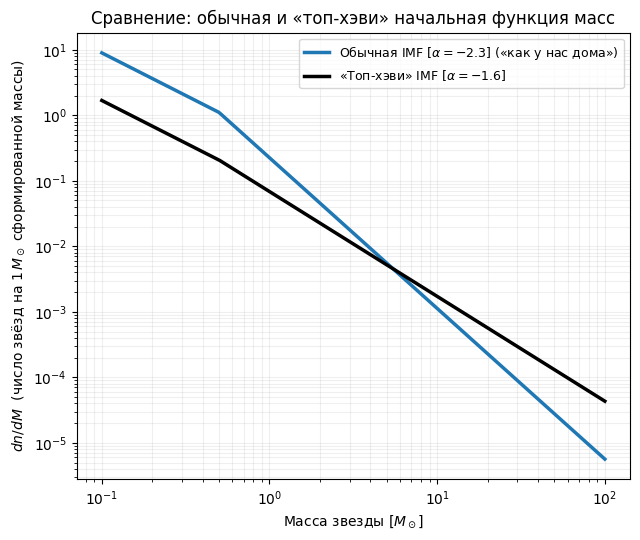

Та же синтетическая популяция (1,000,000 звёзд), «топ-хэви» IMF:
  доля массивных звёзд (>= 8 Msun): 6.70%  (примерно 1 массивная звезда на каждые 15 новорождённых)

Итог: доля массивных звёзд выросла примерно в 9.4 раза (с 1 на ~141 до 1 на ~15) — при абсолютно той же массе газа, ушедшей в звёзды.


In [2]:
# --- Overlay: usual vs top-heavy IMF, plus the same population stats for top-heavy ---
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for alpha, label, color in [
    (ALPHA_KROUPA, r"Обычная IMF [$\alpha=-2.3$] («как у нас дома»)", "#1f77b4"),
    (ALPHA_TOPHEAVY, r"«Топ-хэви» IMF [$\alpha=-1.6$]", "black"),
]:
    ax.plot(M_grid, imf_dndM(M_grid, alpha), color=color, lw=2.5, label=label)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Масса звезды [$M_\odot$]")
ax.set_ylabel(r"$dn/dM$  (число звёзд на $1\,M_\odot$ сформированной массы)")
ax.set_title("Сравнение: обычная и «топ-хэви» начальная функция масс")
ax.legend(fontsize=9)
ax.grid(alpha=0.2, which="both")
fig.tight_layout()
fig.savefig(OUT_DIR / "imf_explainer_comparison.png", dpi=140)
plt.show()

masses_topheavy = sample_masses(ALPHA_TOPHEAVY, N_STARS, rng)
frac_massive_th = np.mean(masses_topheavy >= 8)
one_in_n_th = 1.0 / frac_massive_th

print(f"Та же синтетическая популяция ({N_STARS:,} звёзд), «топ-хэви» IMF:")
print(f"  доля массивных звёзд (>= 8 Msun): {frac_massive_th:.2%}  "
      f"(примерно 1 массивная звезда на каждые {one_in_n_th:.0f} новорождённых)")
print()
print(f"Итог: доля массивных звёзд выросла примерно в {frac_massive_th/frac_massive:.1f} раза "
      f"(с 1 на ~{one_in_n:.0f} до 1 на ~{one_in_n_th:.0f}) — при абсолютно той же массе газа, ушедшей в звёзды.")


## Заключение — в чём главная мысль статьи

Разница между двумя кривыми на графике выше — это и есть весь механизм, который предлагают авторы. Сдвиньте рецепт
звёздообразования всего на один параметр ($\alpha$ на высокомассовом конце), и из того же самого газа получается в разы
больше по-настоящему тяжёлых, ярких звёзд — а именно массивные звёзды непропорционально сильно светят в ультрафиолете.

Логика статьи: газ в ранней Вселенной — плотный, холодный, ещё бедный тяжёлыми элементами — с большей вероятностью рождает
именно «топ-хэви» популяции звёзд. Если так, то самые первые галактики должны светиться в ультрафиолете куда ярче, чем
предсказывают модели со стандартной, «домашней» IMF — а это ровно то, что неожиданно увидел телескоп Джеймса Уэбба:
избыток непонятно ярких галактик на z ≥ 7 (то есть в первый миллиард лет истории Вселенной).

Авторы прогнали полноценную космологическую симуляцию с такой переменной IMF и подтвердили: механизм действительно
работает и правда делает ранние галактики ярче настолько, насколько нужно. Но у решения есть и цена — та же самая
избыточная популяция массивных звёзд означает избыточное число сверхновых, металлов и пыли, а в диапазоне 7 ≲ z ≲ 10
модель слегка «переигрывает», предсказывая чуть больше обычных (не самых ярких) галактик, чем показывают наблюдения.
Один параметр одной функции — а последствий для всей картины формирования галактик оказывается на удивление много.